# GLM and Permutation Tests

In [25]:
import sys
import os
%matplotlib inline
sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from statsmodels.stats.multitest import multipletests
from analyses.single_neuron_analysis import run_glm, plot_glm_coefficients, run_permutation_anova, \
    plot_permutation_anova_results_summary, merge_glm_and_permutation_anova
# Notebook header
import pandas as pd
from analyses.spike_count import prepare_binned_spike_data, aggregate_trial_level
import warnings
from scipy.stats import ConstantInputWarning
warnings.simplefilter("ignore", ConstantInputWarning)

## Load Session for Analysis

In [30]:
# Step 1: Load and prepare data
date = "2023-09-27"
round_no = 2
bin_size = 0.05

analysis_df = prepare_binned_spike_data(date, round_no, bin_size)

## Effect of Stimulus Identity for Zombies

In [31]:
zombies_df = analysis_df[analysis_df['MonkeyGroup'] == 'Zombies']
formula = "SpikeCount ~ C(MonkeyName)"  # Stimulus identity


## GLM

In [32]:
glm_results = run_glm(zombies_df, formula=formula)
print(glm_results.head())

Running GLM per neuron: 100%|██████████| 28/28 [00:00<00:00, 61.03it/s]

                   index      Coef.      Std.Err.         z         P>|z|  \
0              Intercept  -5.921578      1.000000 -5.921578  3.188662e-09   
1  C(MonkeyName)[T.143H]   1.125788      1.154701  0.974961  3.295797e-01   
2  C(MonkeyName)[T.151J] -21.647622  30408.350584 -0.000712  9.994320e-01   
3   C(MonkeyName)[T.67G] -21.647622  30655.242461 -0.000706  9.994366e-01   
4   C(MonkeyName)[T.69X]   0.596132      1.224745  0.486740  6.264426e-01   

         [0.025        0.975]                    NeuronID  
0     -7.881542     -3.961614  2023-09-27_2_Channel.C_000  
1     -1.137384      3.388959  2023-09-27_2_Channel.C_000  
2 -59620.919596  59577.624351  2023-09-27_2_Channel.C_000  
3 -60104.818784  60061.523539  2023-09-27_2_Channel.C_000  
4     -1.804323      2.996588  2023-09-27_2_Channel.C_000  


## GLM Multiple Comparison Correction

In [16]:
# ---- multiple comparison correction ---
# select p-value column from glm_results
pvals = glm_results['P>|z|']
# correction method: 'fdr_bh' (False Discovery Rate, Benjamini/Hochberg)
reject, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')

# add corrected p-value and reject to glm_results
glm_results['pval_corrected'] = pvals_corrected
glm_results['significant'] = reject

In [23]:
# glm_results.to_excel('glm_results.xlsx')

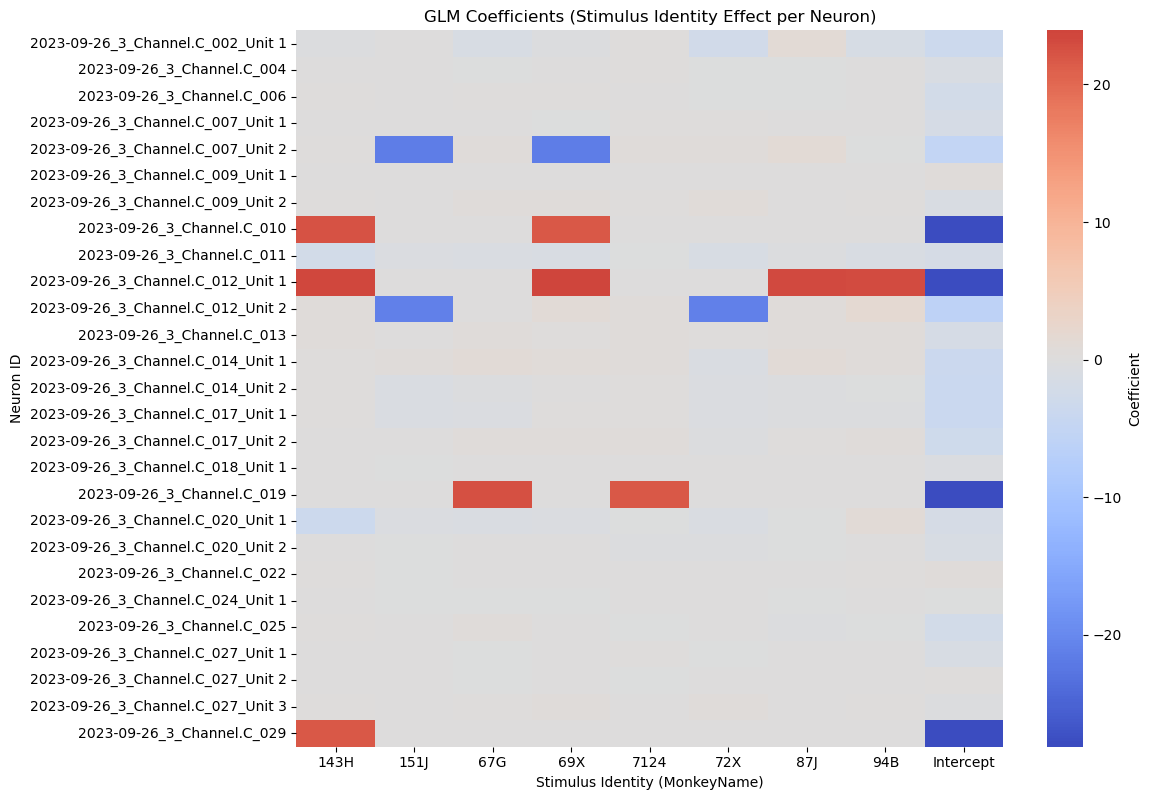

In [17]:
plot_glm_coefficients(glm_results)

## Permutation ANOVA

In [18]:
zombies_trial_df= aggregate_trial_level(zombies_df)
# unique_neurons = zombies_trial_df['NeuronID'].unique()
# neuron_df = zombies_trial_df[zombies_trial_df['NeuronID'] == unique_neurons[0]]
zombies_trial_df.head()

,NeuronID,TaskField,MonkeyName,MonkeyGroup,SpikeCount
0,2023-09-26_3_Channel.C_002_Unit 1,1695753699241000,143H,Zombies,4
1,2023-09-26_3_Channel.C_002_Unit 1,1695753699414000,143H,Zombies,1
2,2023-09-26_3_Channel.C_002_Unit 1,1695753699562000,7124,Zombies,0
3,2023-09-26_3_Channel.C_002_Unit 1,1695753699874000,110E,Zombies,1
4,2023-09-26_3_Channel.C_002_Unit 1,1695753699967000,7124,Zombies,7


Running permutation ANOVA per neuron:   0%|          | 0/32 [00:00<?, ?it/s]

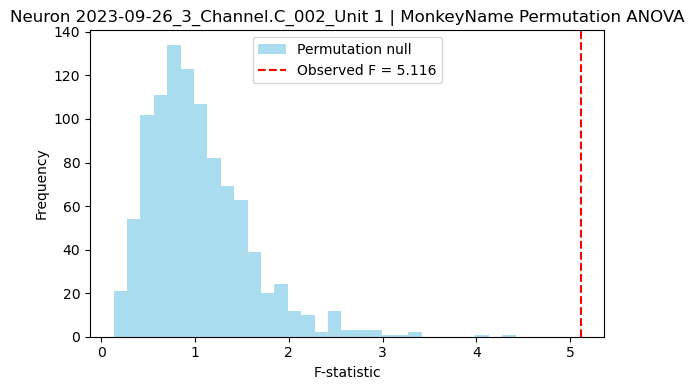

Running permutation ANOVA per neuron:   6%|▋         | 2/32 [00:00<00:05,  5.85it/s]

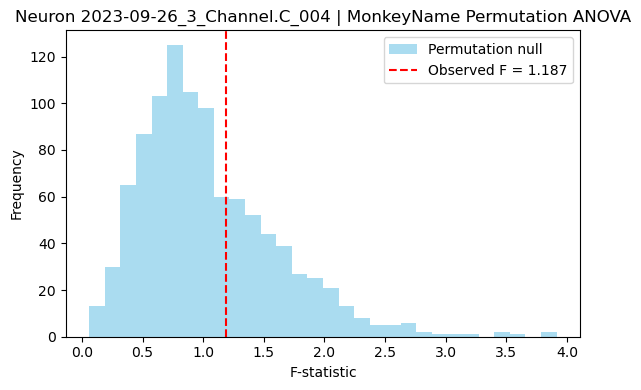

Running permutation ANOVA per neuron:  12%|█▎        | 4/32 [00:00<00:04,  5.84it/s]

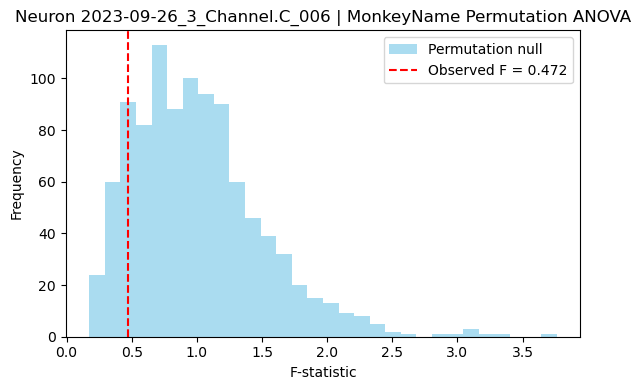

Running permutation ANOVA per neuron:  16%|█▌        | 5/32 [00:00<00:05,  5.30it/s]

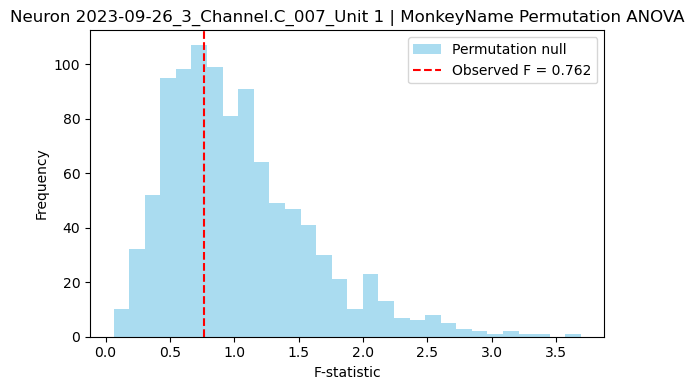

Running permutation ANOVA per neuron:  19%|█▉        | 6/32 [00:01<00:05,  5.05it/s]

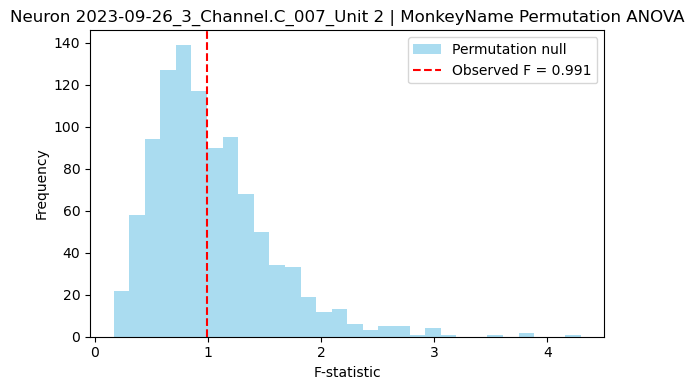

Running permutation ANOVA per neuron:  22%|██▏       | 7/32 [00:01<00:05,  4.88it/s]

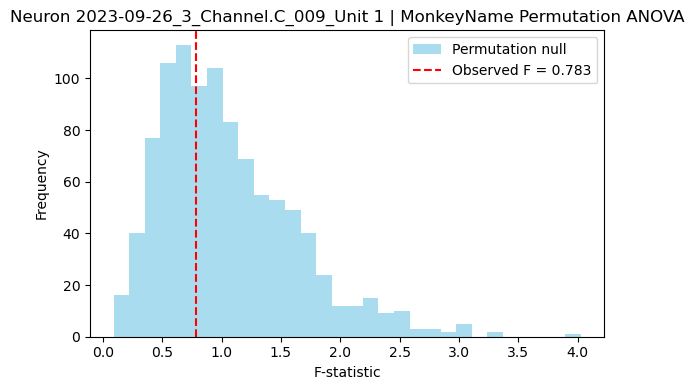

Running permutation ANOVA per neuron:  25%|██▌       | 8/32 [00:01<00:05,  4.78it/s]

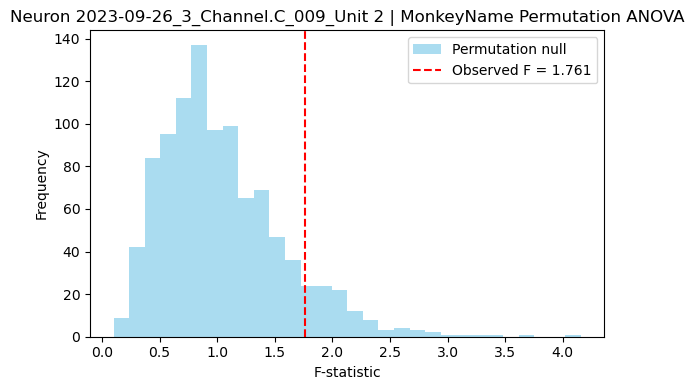

Running permutation ANOVA per neuron:  28%|██▊       | 9/32 [00:01<00:04,  4.69it/s]

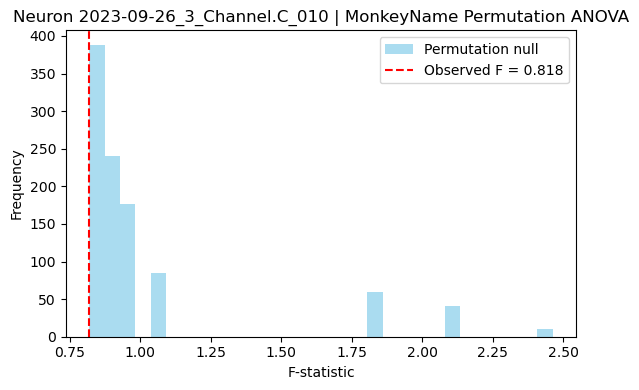

Running permutation ANOVA per neuron:  31%|███▏      | 10/32 [00:02<00:04,  4.63it/s]

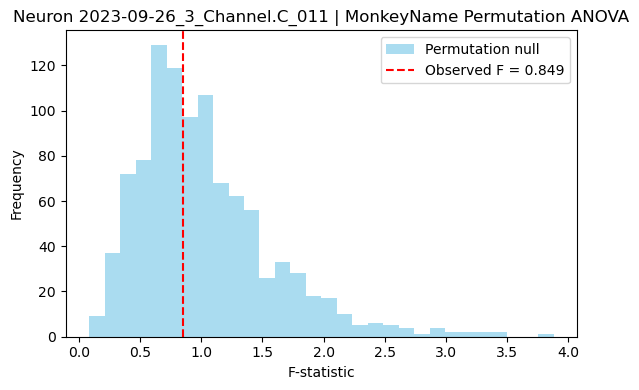

Running permutation ANOVA per neuron:  34%|███▍      | 11/32 [00:02<00:04,  4.62it/s]

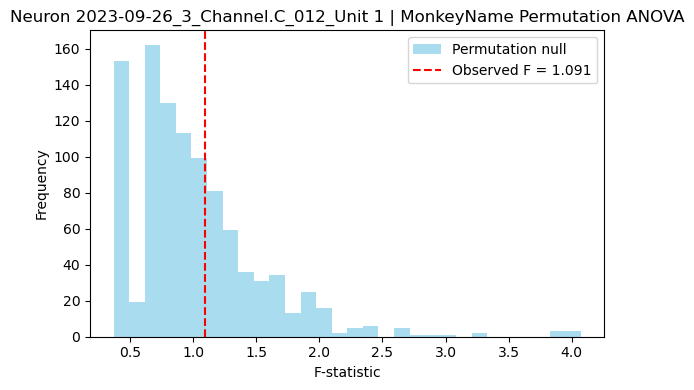

Running permutation ANOVA per neuron:  38%|███▊      | 12/32 [00:02<00:04,  4.56it/s]

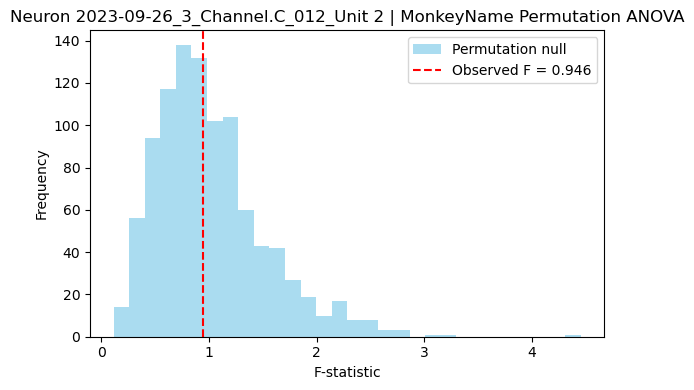

Running permutation ANOVA per neuron:  41%|████      | 13/32 [00:02<00:04,  4.60it/s]

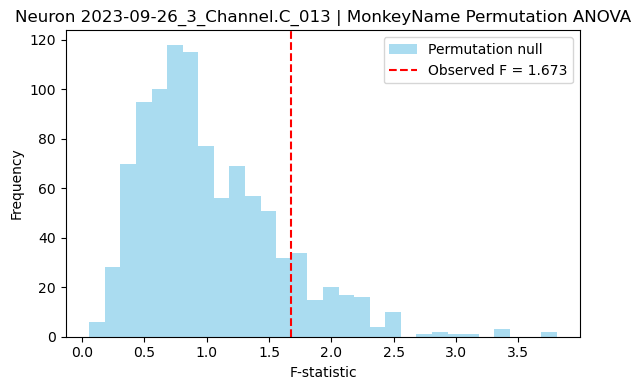

Running permutation ANOVA per neuron:  44%|████▍     | 14/32 [00:02<00:03,  4.56it/s]

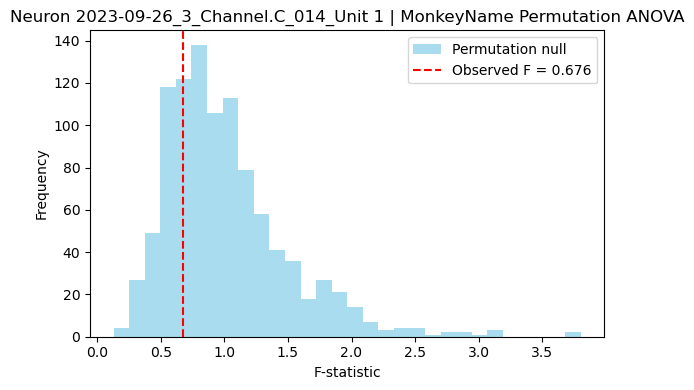

Running permutation ANOVA per neuron:  47%|████▋     | 15/32 [00:03<00:03,  4.56it/s]

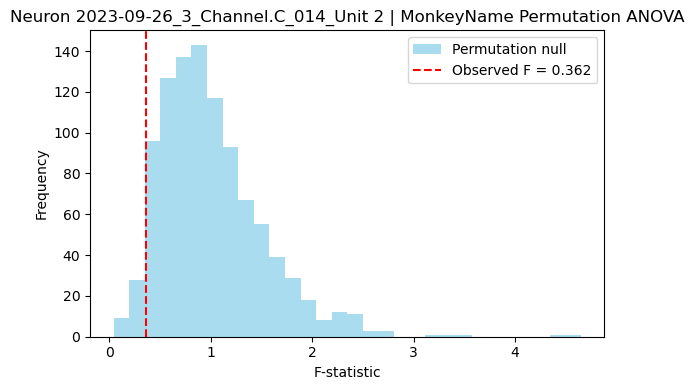

Running permutation ANOVA per neuron:  50%|█████     | 16/32 [00:03<00:03,  4.59it/s]

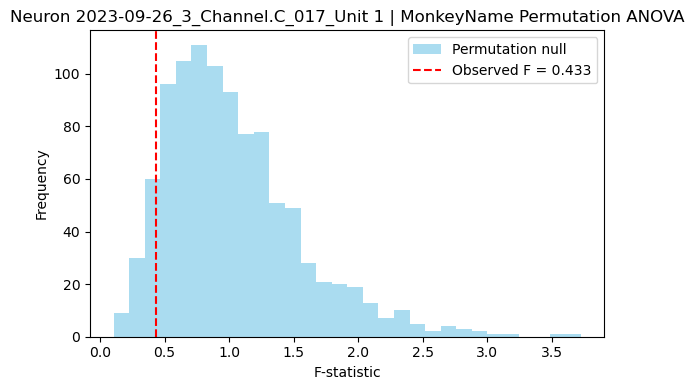

Running permutation ANOVA per neuron:  53%|█████▎    | 17/32 [00:03<00:03,  4.60it/s]

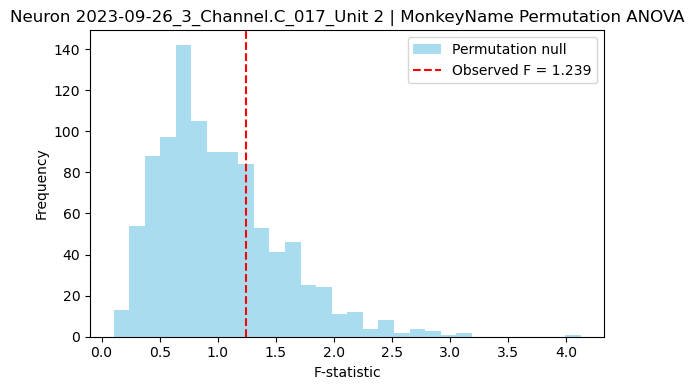

Running permutation ANOVA per neuron:  56%|█████▋    | 18/32 [00:03<00:03,  4.56it/s]

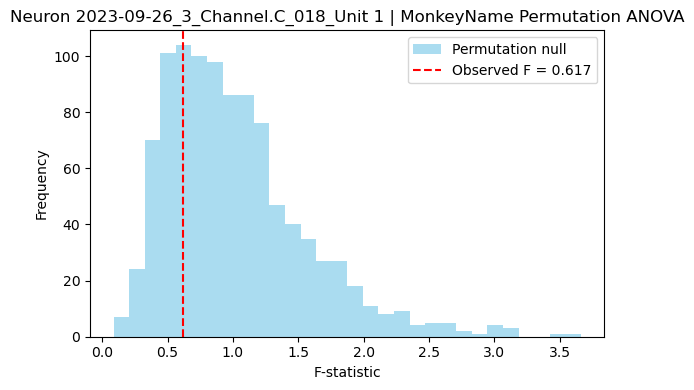

Running permutation ANOVA per neuron:  59%|█████▉    | 19/32 [00:04<00:02,  4.58it/s]

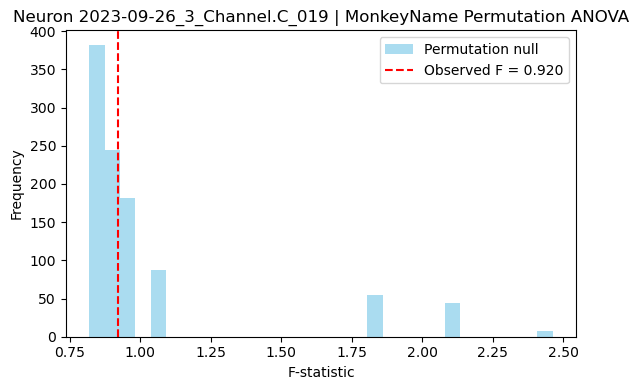

Running permutation ANOVA per neuron:  62%|██████▎   | 20/32 [00:04<00:03,  3.76it/s]

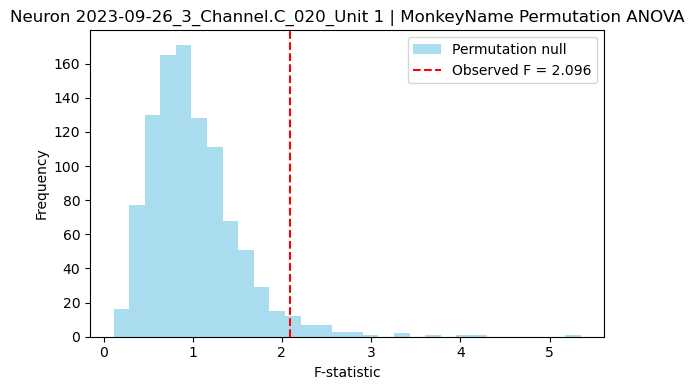

Running permutation ANOVA per neuron:  66%|██████▌   | 21/32 [00:04<00:02,  3.97it/s]

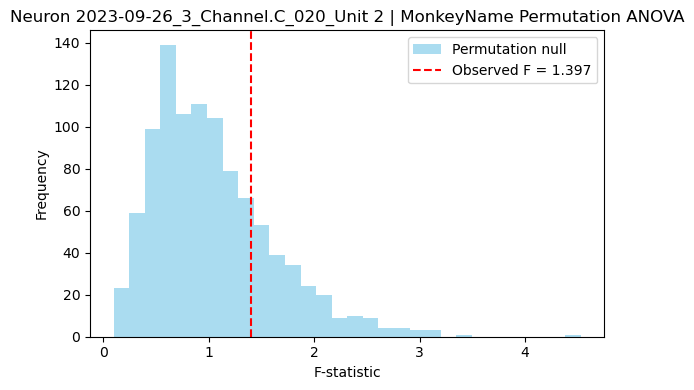

Running permutation ANOVA per neuron:  72%|███████▏  | 23/32 [00:04<00:01,  4.82it/s]

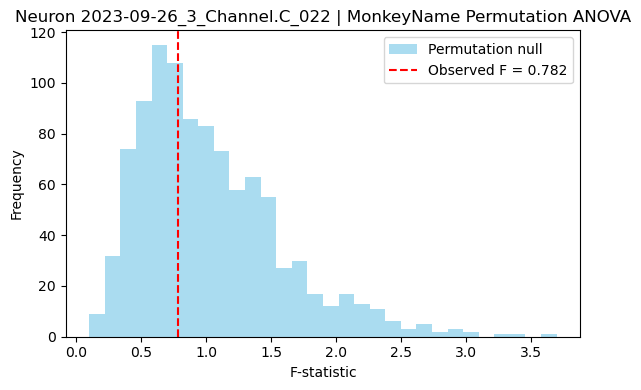

Running permutation ANOVA per neuron:  75%|███████▌  | 24/32 [00:05<00:01,  4.73it/s]

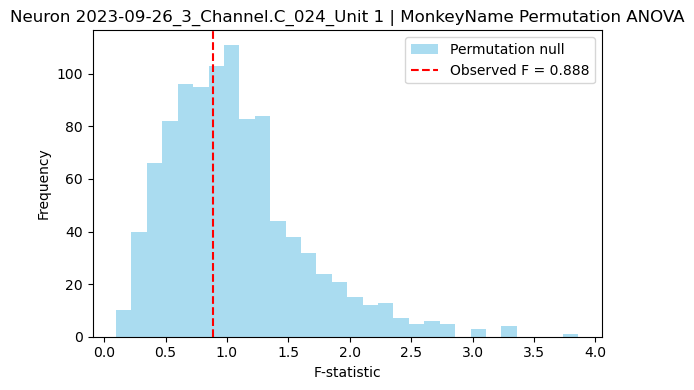

Running permutation ANOVA per neuron:  78%|███████▊  | 25/32 [00:05<00:01,  4.68it/s]

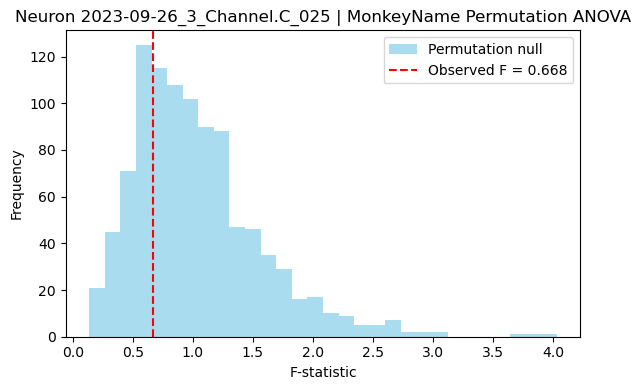

Running permutation ANOVA per neuron:  84%|████████▍ | 27/32 [00:05<00:00,  5.18it/s]

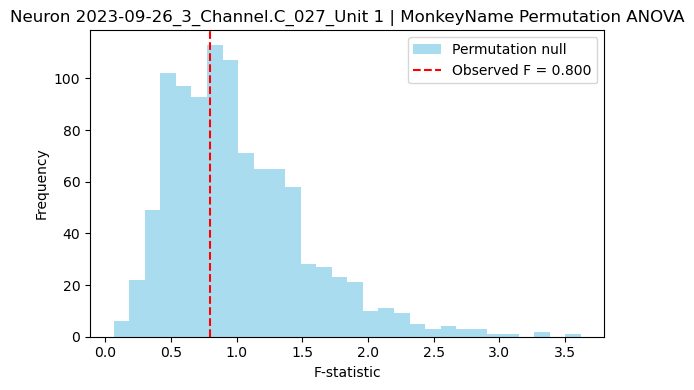

Running permutation ANOVA per neuron:  88%|████████▊ | 28/32 [00:05<00:00,  4.96it/s]

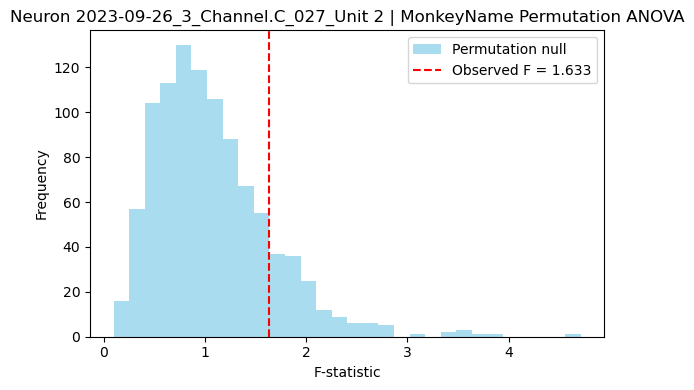

Running permutation ANOVA per neuron:  91%|█████████ | 29/32 [00:06<00:00,  4.84it/s]

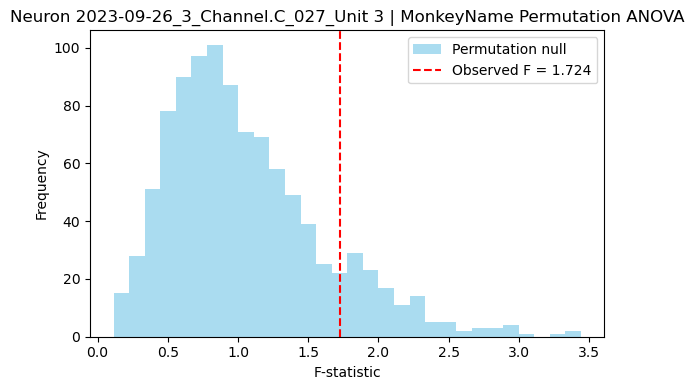

Running permutation ANOVA per neuron:  97%|█████████▋| 31/32 [00:06<00:00,  5.33it/s]

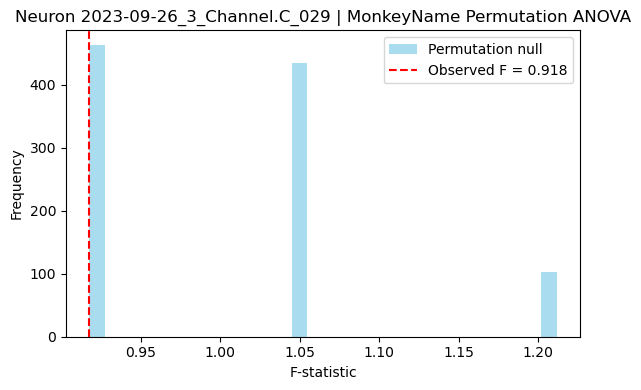

Running permutation ANOVA per neuron: 100%|██████████| 32/32 [00:06<00:00,  4.74it/s]


Results:
                             NeuronID  F-statistic  p-value
0   2023-09-26_3_Channel.C_002_Unit 1     5.116338    0.000
1          2023-09-26_3_Channel.C_004     1.186998    0.322
2          2023-09-26_3_Channel.C_006     0.472202    0.872
3   2023-09-26_3_Channel.C_007_Unit 1     0.761809    0.632
4   2023-09-26_3_Channel.C_007_Unit 2     0.990568    0.448
5   2023-09-26_3_Channel.C_009_Unit 1     0.783351    0.621
6   2023-09-26_3_Channel.C_009_Unit 2     1.761453    0.103
7          2023-09-26_3_Channel.C_010     0.818452    0.894
8          2023-09-26_3_Channel.C_011     0.848581    0.552
9   2023-09-26_3_Channel.C_012_Unit 1     1.091445    0.337
10  2023-09-26_3_Channel.C_012_Unit 2     0.946060    0.480
11         2023-09-26_3_Channel.C_013     1.673057    0.127
12  2023-09-26_3_Channel.C_014_Unit 1     0.676258    0.755
13  2023-09-26_3_Channel.C_014_Unit 2     0.361645    0.955
14  2023-09-26_3_Channel.C_017_Unit 1     0.433197    0.919
15  2023-09-26_3_Channel.C_017

In [19]:
perm_anova_results = run_permutation_anova(zombies_trial_df, category_col='MonkeyName', plot=True)

In [27]:
plot_permutation_anova_results_summary(perm_anova_results)

In [28]:
merge_glm_and_permutation_anova(glm_results, perm_anova_results)

,NeuronID,GLM_p-value,F-statistic,PermANOVA_p-value,GLM_pval_corrected,GLM_significant,Permutation_pval_corrected,Permutation_significant
0,2023-09-26_3_Channel.C_002_Unit 1,6.692064e-37,5.116338,0.000,1.505714e-36,True,0.000000,True
1,2023-09-26_3_Channel.C_004,6.859976e-32,1.186998,0.336,1.089526e-31,True,0.849150,False
2,2023-09-26_3_Channel.C_006,1.313429e-50,0.472202,0.913,1.182086e-49,True,0.947000,False
3,2023-09-26_3_Channel.C_007_Unit 1,4.380422e-49,0.761809,0.620,2.365428e-48,True,0.849150,False
4,2023-09-26_3_Channel.C_007_Unit 2,4.405745e-14,0.990568,0.433,5.947755e-14,True,0.849150,False
5,2023-09-26_3_Channel.C_009_Unit 1,4.223756e-108,0.783351,0.608,1.140414e-106,True,0.849150,False
6,2023-09-26_3_Channel.C_009_Unit 2,4.163036e-32,1.761453,0.114,7.480228e-32,True,0.513000,False
7,2023-09-26_3_Channel.C_010,9.993343e-01,0.818452,0.902,9.994115e-01,False,0.947000,False
8,2023-09-26_3_Channel.C_011,1.799178e-47,0.848581,0.542,6.072225e-47,True,0.849150,False
9,2023-09-26_3_Channel.C_012_Unit 1,9.994115e-01,1.091445,0.340,9.994115e-01,False,0.849150,False


In [33]:
glm_results.groupby('NeuronID')[['pval_corrected','P>|z|']].min().reset_index()

,NeuronID,pval_corrected,P>|z|
0,2023-09-26_3_Channel.C_002_Unit 1,1.355143e-35,6.692064e-37
1,2023-09-26_3_Channel.C_004,9.805730e-31,6.859976e-32
2,2023-09-26_3_Channel.C_006,1.063877e-48,1.313429e-50
3,2023-09-26_3_Channel.C_007_Unit 1,2.128885e-47,4.380422e-49
4,2023-09-26_3_Channel.C_007_Unit 2,4.866345e-13,4.405745e-14
5,2023-09-26_3_Channel.C_009_Unit 1,1.026373e-105,4.223756e-108
6,2023-09-26_3_Channel.C_009_Unit 2,6.732205e-31,4.163036e-32
7,2023-09-26_3_Channel.C_010,1.000000e+00,9.993343e-01
8,2023-09-26_3_Channel.C_011,5.465003e-46,1.799178e-47
9,2023-09-26_3_Channel.C_012_Unit 1,1.000000e+00,9.994115e-01
